In [11]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append('../src')
from pre_processing import df_transform_experimental, prepare_for_training
import os
os.environ["WANDB_SILENT"] = "true"
import wandb
import pandas as pd

DATA_PATH = '../data/train.csv'
CLASS_NAMES = ["Clutter", "Cormorants", "Pigeons", "Ducks", "Geese", "Gulls", "Birds of Prey", "Waders", "Songbirds"]

from feature_config import features_config

df = pd.read_csv(DATA_PATH)
transformed = df_transform_experimental(df, features_config, True)
X, y, features = prepare_for_training(transformed, features_config, CLASS_NAMES)

y[y != 1] = 0
y

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


0       0
1       0
2       0
3       0
4       0
       ..
2596    0
2597    0
2598    0
2599    0
2600    0
Name: bird_group, Length: 2601, dtype: int64

In [12]:
from xgboost_train import run_cv_training_xgboost_cormorants
from custom_scoring import calculate_macro_ap

params = {
            'n_estimators': 1000,
            'learning_rate': 0.05,
            'max_depth': 6,
            'objective': 'binary:logistic',
            'num_class': 2,
            'tree_method': 'hist',
            'early_stopping_rounds': 100,
            'random_state': 42,
            'use_weights': True,
        }

config = {
    'params':params,
    'feature_version':features,
}

models, oof_preds= run_cv_training_xgboost_cormorants(X, y, class_names=['Other','Cormorants'], params=params)

Fold 1 | Best Iter: 26 | Score: 0.2918
Fold 2 | Best Iter: 145 | Score: 0.4005
Fold 3 | Best Iter: 440 | Score: 0.4515
Fold 4 | Best Iter: 41 | Score: 0.4114
Fold 5 | Best Iter: 635 | Score: 0.3840


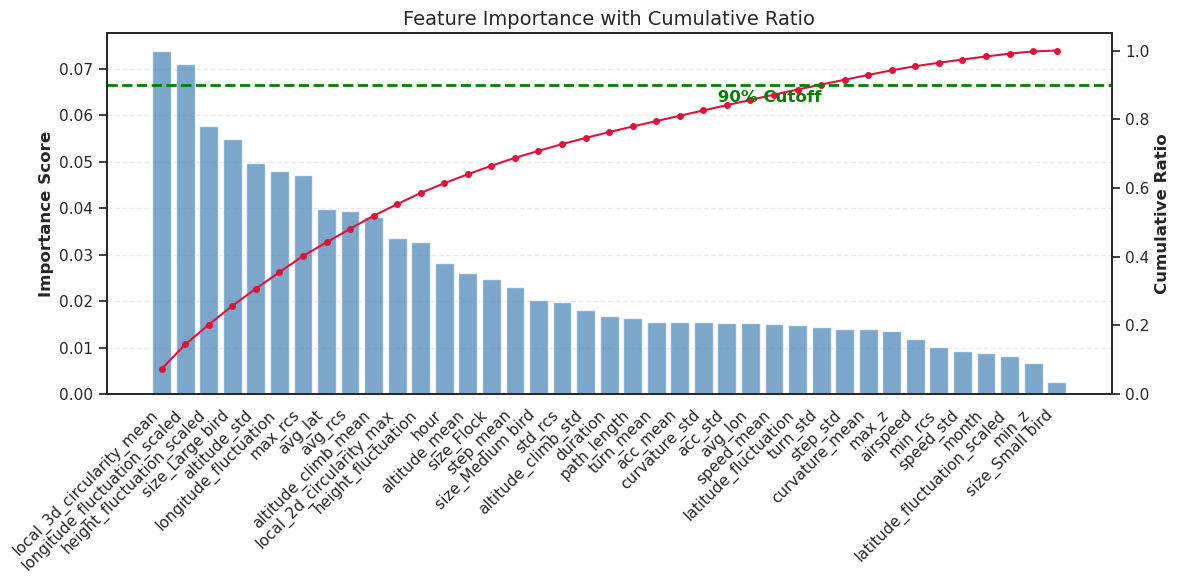

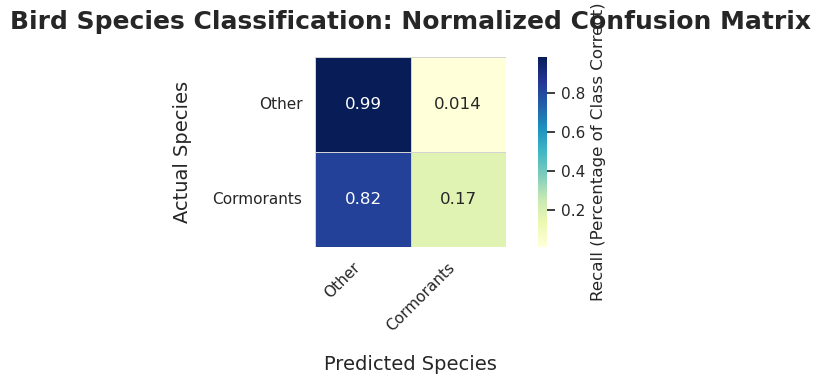

In [13]:
from result_analysis import plot_cumulative_importance
from result_analysis import plot_bird_confusion_pretty
plot_cumulative_importance(models, features)
plot_bird_confusion_pretty(y, oof_preds, class_names=["Other","Cormorants"])